In [3]:


from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# Enable interactive plot
%matplotlib notebook
%matplotlib notebook

import subprocess
import sys

# Import PySwarms
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)
from pyswarms.utils.plotters.formatters import Mesher

global particle_number
particle_number=0

from math import floor

import random

In [141]:
push_data = pd.read_csv('AllQtyDF.csv',sep=";")[['MaxForce', 'PerturbationDuration','Final_CoM_y','angle','StepIndex','Impulse','height','mass']]
push_data = push_data.loc[push_data['angle']==90]
push_data2 = push_data.loc[push_data['StepIndex']==2]
push_data2=push_data2[['MaxForce', 'PerturbationDuration','Final_CoM_y','Impulse','height','mass']]
push_data = push_data
push_data=push_data[['MaxForce', 'PerturbationDuration','Final_CoM_y','Impulse','height','mass']]

push_data = push_data.sort_values(by=['Impulse'])
push_data2 = push_data2.sort_values(by=['Impulse'])


251


<IPython.core.display.Javascript object>


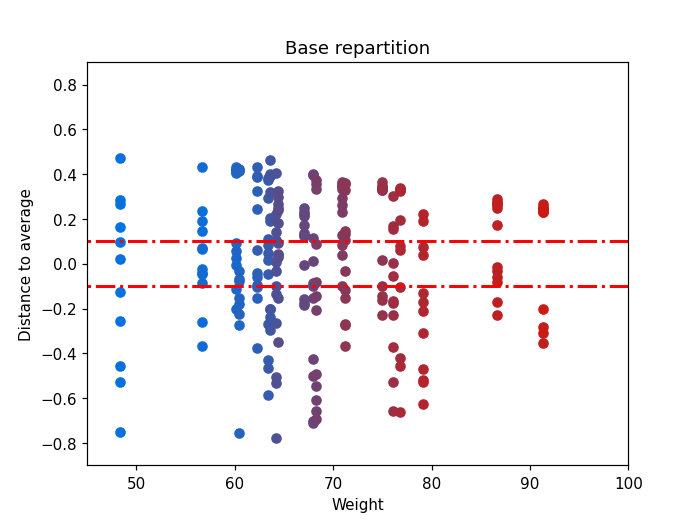

1.735
67.0


In [158]:
def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)

push_data = push_data.sort_values(by=['mass'])

cmap = get_cmap(len(push_data))

print(len(push_data))
x2=[]
y2=[]
x=[]
y=[]
plt.xlabel('Weight')
plt.ylabel('Distance to average')
plt.title('Base repartition')
    
    
#plt.ylim(-0.3,1.6)
plt.ylim(-0.9,0.9)
plt.xlim(45,100)
 
plt.plot([-0.1, 100], [0.1, 0.1], 'r-.', lw=2)
plt.plot([-0.1, 100], [-0.1, -0.1], 'r-.', lw=2)
#plt.plot([-100, -0.1], [1000, -0.1], 'r-', lw=2)

average_h = push_data2.loc[:, 'height'].median()
average_m = push_data2.loc[:, 'mass'].median()
print(average_h)
print(average_m)

for i in range(len(push_data)):
    ratio = 1+((push_data.iloc[i][4]-average_h)/average_h+(push_data.iloc[i][5]-average_m)/average_m)
    ratio=1
    x.append(push_data.iloc[i][5])
    y.append(push_data.iloc[i][2]*ratio)
    
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef) 

for i in range(len(push_data)):
    ratio = 1+((push_data.iloc[i][4]-average_h)/average_h+(push_data.iloc[i][5]-average_m)/average_m)
    ratio=1
    x2 = push_data.iloc[i][5]
    y2 = poly1d_fn(x2)-push_data.iloc[i][2]*ratio
    plt.scatter(x2,y2, color=color_array[i])

# poly1d_fn is now a function which takes in x and returns an estimate for y
#plt.plot( x, poly1d_fn(x), 'r-')
#print(coef)

#plt.plot([0, 2], [0, 2], 'g-', lw=2)

#plot_cost_history(cost_history=optimizer.cost_history)
#print(str(np.sum(y)/len(y)))
plt.show()

In [143]:
color1 = "#0073E5"
color2 = "#D51609"

def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]

color_array = get_color_gradient(color1, color2, len(push_data))